# 02. 피처 엔지니어링 & A/B 실험
**입력**: `train_clean.parquet`, `test_clean.parquet`  
**산출물**: `train_features.parquet`, `test_features.parquet`

파생변수 그룹:
- **A. 시술 이력** — ever_delivered, is_first_attempt, repeated_3plus, prev_birth_rate
- **B. 배아 파이프라인** — is_FET, 배아 구간, log 변환, 전환율
- **C. 특정 시술 유형 분해** — 주기법, is_배반포, is_반복시도
- **D. 나이 & 상호작용** — 나이_구간, 나이×시술횟수
- **E. CV A/B 실험**으로 기여도 검증

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import sys
import subprocess

# scikit-learn을 먼저 설치해야 lightgbm이 sklearn wrapper를 활성화함
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn", "lightgbm"])

import lightgbm
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

print(lightgbm.__version__)
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

TARGET = '임신 성공 여부'
ID_COL = 'ID'

4.6.0



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
train = pd.read_parquet('train_clean.parquet')
test  = pd.read_parquet('test_clean.parquet')

print(f'train: {train.shape}  test: {test.shape}')

train: (256351, 96)  test: (90067, 95)


## Group A. 시술 이력 기반 파생변수 (Templeton 기반)
우선순위 1 — 문헌 검증된 가장 강력한 예측 변수

In [6]:
def add_history_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    total_procs  = df['총 시술 횟수'].astype(float)
    total_births = df['총 출산 횟수'].astype(float)
    total_preg   = df['총 임신 횟수'].astype(float)

    # Templeton 1996 핵심 피처
    df['ever_delivered']   = (total_births > 0).astype(int)      # 최강 긍정 신호
    df['is_first_attempt'] = (total_procs == 0).astype(int)      # 첫 시도
    df['repeated_3plus']   = (total_procs >= 3).astype(int)      # 반복 실패 (강한 부정)

    # 비율 피처
    df['prev_birth_rate']  = total_births / (total_preg + 1)     # 과거 임신→출산 유지율
    df['유산_횟수']         = (total_preg - total_births).clip(lower=0)  # 유산 횟수

    # 임신 경과 연수 (96% 결측 → 결측 플래그와 함께 활용)
    if '임신 시도 또는 마지막 임신 경과 연수' in df.columns:
        df['long_infertility'] = (
            (df['임신 시도 또는 마지막 임신 경과 연수'] >= 7) &
            (df['임신경과연수_missing'] == 0)  # 결측 아닌 경우만
        ).astype(int)

    # 시술 경험 레벨 (0=첫 시도, 1=1~2회, 2=3~5회, 3=6회+)
    df['시술경험레벨'] = pd.cut(
        total_procs,
        bins=[-1, 0, 2, 5, 100],
        labels=[0, 1, 2, 3]
    ).astype(int)

    return df


train = add_history_features(train)
test  = add_history_features(test)

# 검증
feat_a = ['ever_delivered', 'is_first_attempt', 'repeated_3plus', 'prev_birth_rate', '유산_횟수']
print(train.groupby('ever_delivered')[TARGET].mean())
print(train[feat_a].describe().round(3))

ever_delivered
0    0.256851
1    0.267012
Name: 임신 성공 여부, dtype: float64
       ever_delivered  is_first_attempt  repeated_3plus  prev_birth_rate  \
count      256351.000        256351.000      256351.000       256351.000   
mean            0.147             0.381           0.244            0.073   
std             0.355             0.486           0.430            0.177   
min             0.000             0.000           0.000            0.000   
25%             0.000             0.000           0.000            0.000   
50%             0.000             0.000           0.000            0.000   
75%             0.000             1.000           0.000            0.000   
max             1.000             1.000           1.000            0.857   

            유산_횟수  
count  256351.000  
mean        0.072  
std         0.280  
min         0.000  
25%         0.000  
50%         0.000  
75%         0.000  
max         4.000  


## Group B. 배아 파이프라인 파생변수
IVF 7단계 추적 — 개수보다 전환율이 예후를 더 잘 반영

In [7]:
def add_embryo_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    total_emb   = df['총 생성 배아 수'].astype(float)
    icsi_inj    = df['미세주입된 난자 수'].astype(float)
    icsi_emb    = df['미세주입에서 생성된 배아 수'].astype(float)
    transferred = df['이식된 배아 수'].astype(float)
    stored      = df['저장된 배아 수'].astype(float)
    thawed      = df['해동된 배아 수'].astype(float)
    fresh_eggs  = df['수집된 신선 난자 수'].astype(float)

    # ── FET vs 신선 주기 분류 ──
    df['is_FET']   = (thawed > 0).astype(int)          # 동결배아이식 주기
    df['is_fresh'] = (df['신선 배아 사용 여부'] == 1.0).astype(int)

    # ── 배아 수 그룹 (Bologna·POSEIDON 기준) ──
    # 저반응(0~6) / 정상반응(7~14) / 고반응(15~20) / 과반응(21+)
    df['배아수_그룹'] = pd.cut(
        total_emb,
        bins=[-1, 6, 14, 20, 9999],
        labels=[0, 1, 2, 3]
    ).astype(float).fillna(0).astype(int)

    df['배아_있음']  = (total_emb > 0).astype(int)
    df['배아_풍부']  = (total_emb >= 5).astype(int)
    df['log_배아수'] = np.log1p(total_emb)  # 트리 모델용 연속변수 보완

    # ── 파이프라인 전환율 ──
    df['성숙률']         = icsi_inj  / (fresh_eggs + 1)         # 난자채취 → ICSI 주입
    df['ICSI_수정발달률'] = icsi_emb  / (icsi_inj + 1)          # ICSI 주입 → 배아 생성
    df['이식가능률']      = (transferred + stored) / (total_emb + 1)  # 생성배아 → 이식/저장
    df['이식채택률']      = transferred / (transferred + stored + 1)   # 이식 vs 저장 비율

    # ── OHSS 의심: 고반응 + 이식 안 함 ──
    df['OHSS_의심'] = ((total_emb >= 15) & (transferred == 0)).astype(int)

    return df


train = add_embryo_features(train)
test  = add_embryo_features(test)

# FET vs 신선 성공률 비교
print('FET별 성공률:')
print(train.groupby('is_FET')[TARGET].agg(['mean', 'count']).round(3))
print('\n배아수_그룹별 성공률:')
print(train.groupby('배아수_그룹')[TARGET].agg(['mean', 'count']).round(3))

FET별 성공률:
         mean   count
is_FET               
0       0.264  215966
1       0.229   40385

배아수_그룹별 성공률:
         mean   count
배아수_그룹               
0       0.217  175650
1       0.353   70336
2       0.332    8492
3       0.226    1873


## Group C. 특정 시술 유형 피처 분해 (전략 3)
24개 카테고리 → 4개 의미 단위로 분해

In [8]:
def add_procedure_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    s = df['특정 시술 유형'].fillna('Unknown')

    df['주기법_ICSI']   = s.str.contains('ICSI', case=False).astype(int)
    df['주기법_IVF']    = s.str.contains(r'^IVF', case=False, regex=True).astype(int)
    df['is_배반포']     = s.str.contains('BLASTOCYST', case=False).astype(int)  # 긍정 신호
    df['is_반복시도']   = s.str.contains(':', regex=False).astype(int)           # 부정 신호 (성공률 ~1%)
    df['is_조합시술']   = s.str.contains('/', regex=False).astype(int)
    df['is_Unknown']    = (s == 'Unknown').astype(int)

    return df


train = add_procedure_features(train)
test  = add_procedure_features(test)

print('반복시도별 성공률:')
print(train.groupby('is_반복시도')[TARGET].agg(['mean', 'count']).round(3))
print('\n배반포별 성공률:')
print(train.groupby('is_배반포')[TARGET].agg(['mean', 'count']).round(3))

반복시도별 성공률:
          mean   count
is_반복시도               
0        0.262  251304
1        0.078    5047

배반포별 성공률:
         mean   count
is_배반포               
0       0.257  253483
1       0.361    2868


## Group D. 나이 & 상호작용 피처

In [9]:
def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    age      = df['시술 당시 나이'].astype(float)
    procs    = df['총 시술 횟수'].astype(float)
    total_emb = df['총 생성 배아 수'].astype(float)
    male_fac = df['불임 원인 - 남성 요인'].astype(float)

    # 고령 + 반복 시도 = 최악 조합
    df['나이_X_시술횟수']  = age * procs

    # 같은 배아 수라도 나이별 해석 다름
    df['나이_X_배아수']    = age * np.log1p(total_emb)

    # 남성요인 × ICSI 적합성 (Barnett-Itzhaki 2020: +5.6%p)
    df['남성원인_ICSI_궁합'] = male_fac * df['주기법_ICSI']

    # eSET × 배반포 조합 (Kawwass 2013: 최고 조합)
    if '단일 배아 이식 여부' in df.columns:
        eset = (df['단일 배아 이식 여부'] == 1.0).astype(int)
        df['eSET_배반포'] = eset * df['is_배반포']

    # 시술적합성 종합 점수
    df['시술적합성'] = df['남성원인_ICSI_궁합'] * 2 + df['is_배반포'] - df['is_반복시도']

    return df


train = add_interaction_features(train)
test  = add_interaction_features(test)

feat_d = ['나이_X_시술횟수', '남성원인_ICSI_궁합', 'eSET_배반포']
print(train[[TARGET] + feat_d].groupby(TARGET).mean().round(3))

          나이_X_시술횟수  남성원인_ICSI_궁합  eSET_배반포
임신 성공 여부                                   
0             2.821         0.260     0.003
1             1.731         0.309     0.007


## E. A/B CV 실험
파생변수 그룹을 하나씩 추가하며 AUC 변화 추적

In [10]:
def cv_auc(X: pd.DataFrame, y: pd.Series, name: str, cv=5) -> float:
    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose=-1,
        n_jobs=-1,
    )
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    score = cross_val_score(model, X, y, cv=skf, scoring='roc_auc').mean()
    print(f'{name:<30}: AUC = {score:.5f}')
    return score


# 기증자 연령대 문자열 → 숫자 변환 (LightGBM은 문자열 컬럼 불가)
_age_map = {
    '알 수 없음': float('nan'),
    '만20세 이하': 19.0,
    '만21-25세':  23.0,
    '만26-30세':  28.0,
    '만31-35세':  33.0,
    '만36-40세':  38.0,
    '만41-45세':  43.0,
}
for _col in ['난자 기증자 나이', '정자 기증자 나이']:
    if _col in train.columns:
        train[_col] = train[_col].map(_age_map)
        test[_col]  = test[_col].map(_age_map)


y = train[TARGET]

# 학습에 쓸 컬럼 (ID, target, 문자열 제외)
exclude = {ID_COL, TARGET, '특정 시술 유형', '시술 유형', '배란 유도 유형', '배아 생성 주요 이유',
           '난자 출처', '정자 출처', '시술 시기 코드'}

all_feats = [c for c in train.columns
             if c not in exclude and pd.api.types.is_numeric_dtype(train[c])]

# 그룹별 피처 정의
base_feats = [c for c in all_feats if c not in (
    ['ever_delivered', 'is_first_attempt', 'repeated_3plus', 'prev_birth_rate', '유산_횟수',
     'long_infertility', '시술경험레벨',
     'is_FET', 'is_fresh', '배아수_그룹', '배아_있음', '배아_풍부', 'log_배아수',
     '성숙률', 'ICSI_수정발달률', '이식가능률', '이식채택률', 'OHSS_의심',
     '주기법_ICSI', '주기법_IVF', 'is_배반포', 'is_반복시도', 'is_조합시술', 'is_Unknown',
     '나이_X_시술횟수', '나이_X_배아수', '남성원인_ICSI_궁합', 'eSET_배반포', '시술적합성']
)]

group_a = ['ever_delivered', 'is_first_attempt', 'repeated_3plus', 'prev_birth_rate', '유산_횟수', '시술경험레벨']
group_b = ['is_FET', '배아수_그룹', '배아_있음', '배아_풍부', 'log_배아수', '성숙률', 'ICSI_수정발달률', '이식가능률', '이식채택률', 'OHSS_의심']
group_c = ['주기법_ICSI', '주기법_IVF', 'is_배반포', 'is_반복시도', 'is_조합시술']
group_d = ['나이_X_시술횟수', '나이_X_배아수', '남성원인_ICSI_궁합', 'eSET_배반포', '시술적합성']

In [11]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

results = {}

feats_b = base_feats + group_a
feats_c = feats_b + group_b
feats_d = feats_c + group_c
feats_e = feats_d + group_d

results['A_baseline']  = cv_auc(train[base_feats], y, 'A: baseline')
results['B_history']   = cv_auc(train[feats_b], y, 'B: + 이력(ever_delivered 등)')
results['C_embryo']    = cv_auc(train[feats_c], y, 'C: + 배아 파이프라인')
results['D_procedure'] = cv_auc(train[feats_d], y, 'D: + 시술 유형 분해')
results['E_interact']  = cv_auc(train[feats_e], y, 'E: + 상호작용')

A: baseline                   : AUC = 0.73741
B: + 이력(ever_delivered 등)     : AUC = 0.73751
C: + 배아 파이프라인                 : AUC = 0.73726
D: + 시술 유형 분해                 : AUC = 0.73738
E: + 상호작용                     : AUC = 0.73710


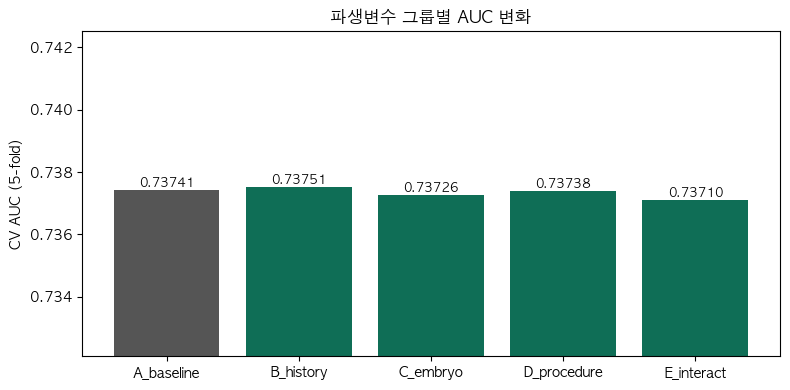


실험별 ΔAUC (이전 대비):
  A_baseline: baseline
  B_history: +0.00009
  C_embryo: +-0.00025
  D_procedure: +0.00012
  E_interact: +-0.00028


In [12]:
# A/B 실험 결과 시각화
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(results.keys())
scores = list(results.values())
bars = ax.bar(labels, scores, color=['#555'] + ['#0f6e56'] * (len(labels)-1))
ax.set_ylim(min(scores) - 0.005, max(scores) + 0.005)
ax.set_ylabel('CV AUC (5-fold)')
ax.set_title('파생변수 그룹별 AUC 변화')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.0001, f'{score:.5f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n실험별 ΔAUC (이전 대비):')
prev = None
for k, v in results.items():
    delta = f'+{v-prev:.5f}' if prev is not None else 'baseline'
    print(f'  {k}: {delta}')
    prev = v

## F. SHAP 피처 중요도 & 최종 피처 선택

shap 미설치: pip install shap


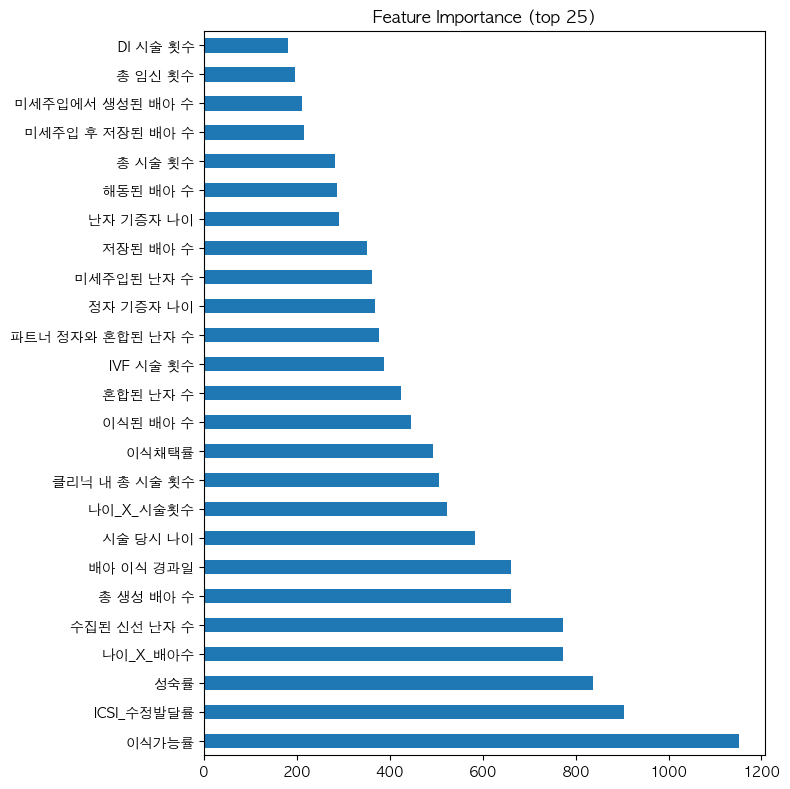

In [13]:
# SHAP 분석 (실험 E 최종 피처셋 기준)
try:
    import shap
    from lightgbm import LGBMClassifier

    model = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    model.fit(train[feats_e], y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(train[feats_e].sample(5000, random_state=42))

    shap.summary_plot(
        shap_values[1] if isinstance(shap_values, list) else shap_values,
        train[feats_e].sample(5000, random_state=42),
        max_display=20,
        show=True
    )
except ImportError:
    print('shap 미설치: pip install shap')
    # LightGBM 자체 feature importance로 대체
    model = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    model.fit(train[feats_e], y)
    fi = pd.Series(model.feature_importances_, index=feats_e).sort_values(ascending=False)
    fi.head(25).plot(kind='barh', figsize=(8, 8), title='Feature Importance (top 25)')
    plt.tight_layout()
    plt.show()

In [14]:
from lightgbm import LGBMClassifier

# 기여도 하위 10% 제거 (실험 F)
model = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1)
model.fit(train[feats_e], y)

fi = pd.Series(model.feature_importances_, index=feats_e)
threshold = 0  # 전혀 기여 안 한 피처(importance=0)만 제거
FINAL_FEATURES = fi[fi > threshold].index.tolist()

print(f'실험 E 피처 수: {len(feats_e)}')
print(f'제거된 피처 수: {len(feats_e) - len(FINAL_FEATURES)}')
print(f'최종 피처 수:   {len(FINAL_FEATURES)}')

results['F_pruned'] = cv_auc(train[FINAL_FEATURES], y, 'F: 하위10% 제거')

실험 E 피처 수: 113
제거된 피처 수: 35
최종 피처 수:   78
F: 하위10% 제거                   : AUC = 0.73714


## 저장

In [15]:
# 최종 피처 목록 저장
import json
with open('final_features.json', 'w', encoding='utf-8') as f:
    json.dump(FINAL_FEATURES, f, ensure_ascii=False, indent=2)

# 전체 파생변수 포함 데이터 저장
train[FINAL_FEATURES + [TARGET, ID_COL]].to_parquet('train_features.parquet', index=False)
test[FINAL_FEATURES + [ID_COL]].to_parquet('test_features.parquet', index=False)

print('저장 완료:')
print('  train_features.parquet')
print('  test_features.parquet')
print('  final_features.json')

저장 완료:
  train_features.parquet
  test_features.parquet
  final_features.json
